# 🎮 Dự Án Game Churn Prediction & Player Analytics
## Notebook 02: Feature Engineering & Preprocessing Pipeline

> **Mục tiêu chính:**
> 1. Xây dựng các đặc trưng mới (Domain-specific Behavioral Features) từ hành vi người chơi nhằm tăng độ chính xác dự báo Churn.
> 2. Tối ưu công thức tính toán `PlayTimePerLevel` và `AchievementsPerLevel` theo đúng logic nghiệp vụ game (loại bỏ việc `+ 1` vào mẫu số, xử lý biên Level 0).
> 3. Gán nhãn bài toán Churn (`IsChurn`) từ mức độ gắn kết (`EngagementLevel`).
> 4. Mã hóa các biến phân loại (Encoding: Ordinal & One-Hot Encoding).
> 5. Tách tập Train/Test chống rò rỉ dữ liệu (Data Leakage prevention).
> 6. Chuẩn hóa đặc trưng (StandardScaler) và lưu trữ dữ liệu sẵn sàng cho Notebook 03 Modeling.

In [1]:
# 1. Khai báo các thư viện cần thiết
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='whitegrid')

---
## 1. Tải dữ liệu thô (Raw Data Ingestion)
Đọc dữ liệu gốc đã được tải về từ thư mục `data/raw/online_gaming_behavior_dataset.csv`.

In [2]:
# 2. Đọc dữ liệu
DATA_PATH = Path('../data/raw/online_gaming_behavior_dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/online_gaming_behavior_dataset.csv')

raw_df = pd.read_csv(DATA_PATH)
print(f"✅ Đã tải dữ liệu thô: {raw_df.shape[0]:,} dòng, {raw_df.shape[1]} cột.")
raw_df.head()

✅ Đã tải dữ liệu thô: 40,034 dòng, 13 cột.


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.526,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.224,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.532,0,Medium,2,131,95,37,Medium


---
## 2. Định nghĩa Biến Mục Tiêu (Target Label Creation)
- **`IsChurn` (Binary Target):**
  - `1` nếu `EngagementLevel == 'Low'` (Người chơi nguy cơ cao hoặc đã rời bỏ).
  - `0` nếu `EngagementLevel in ['Medium', 'High']` (Người chơi gắn bó).
- Tạo thêm nhãn số `EngagementCode` (`{'Low': 0, 'Medium': 1, 'High': 2}`) cho bài toán phân loại đa lớp (Multi-class).

In [3]:
# 3. Gán nhãn Churn
df = raw_df.copy()
df['IsChurn'] = (df['EngagementLevel'] == 'Low').astype(int)
df['EngagementCode'] = df['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})

print('Tỷ lệ phân bố nhãn Churn:')
print(df['IsChurn'].value_counts(normalize=True).apply(lambda x: f'{x*100:.2f}%'))

Tỷ lệ phân bố nhãn Churn:
IsChurn
0    74.21%
1    25.79%
Name: proportion, dtype: object


---
## 3. Tạo Đặc Trưng Mới (Domain-specific Feature Engineering)

> ### 🔍 Đánh giá về dữ liệu thời gian lên cấp:
> - **Hiện trạng:** Tập dữ liệu `online_gaming_behavior_dataset.csv` là tập dữ liệu tổng hợp cấp độ người chơi (User-level aggregated snapshot), **chưa có bảng log chuỗi thời gian (event timestamp log)** ghi nhận thời điểm cụ thể người chơi đạt mốc Level $N$ và Level $N-1$.
> - **Giải pháp tối ưu theo chuẩn Game Analytics:** Khi chỉ có hai biến `PlayTimeHours` và `PlayerLevel`, ta áp dụng logic phân nhánh không làm suy giảm giá trị thực tế ở các level cao:
>   - Với `PlayerLevel == 0`: Tỷ lệ `PlayTimePerLevel = PlayTimeHours` (chưa lên cấp nào).
>   - Với `PlayerLevel >= 1`: Tỷ lệ `PlayTimePerLevel = PlayTimeHours / PlayerLevel` (không cộng thêm 1 vào mẫu số).
>   - Tương tự với `AchievementsPerLevel = AchievementsUnlocked / PlayerLevel` (nếu Level 0 thì bằng `AchievementsUnlocked`).
>   - `AchievementsPerHour = AchievementsUnlocked / PlayTimeHours` (xử lý an toàn nếu PlayTimeHours = 0).
>   - `TotalWeeklyMinutes = SessionsPerWeek * AvgSessionDurationMinutes`.
>   - `EngagementIntensity = AvgSessionDurationMinutes / (PlayTimeHours + 1.0)`.

In [4]:
# 4. Tính toán các đặc trưng mới theo logic chuẩn xác
# Tần suất và thời lượng chơi tuần
df['TotalWeeklyMinutes'] = df['SessionsPerWeek'] * df['AvgSessionDurationMinutes']
df['AvgWeeklyPlayHours'] = df['TotalWeeklyMinutes'] / 60.0

# Tỷ lệ giờ chơi trên từng level (loại trừ level 0, không cộng 1 vào mẫu số)
df['PlayTimePerLevel'] = np.where(
    df['PlayerLevel'] == 0, 
    df['PlayTimeHours'], 
    df['PlayTimeHours'] / df['PlayerLevel']
)

# Tỷ lệ thành tựu theo level
df['AchievementsPerLevel'] = np.where(
    df['PlayerLevel'] == 0,
    df['AchievementsUnlocked'],
    df['AchievementsUnlocked'] / df['PlayerLevel']
)

# Tỷ lệ thành tựu theo giờ chơi
df['AchievementsPerHour'] = np.where(
    df['PlayTimeHours'] == 0,
    0.0,
    df['AchievementsUnlocked'] / df['PlayTimeHours']
)

# Cường độ phiên chơi
df['EngagementIntensity'] = df['AvgSessionDurationMinutes'] / (df['PlayTimeHours'] + 1.0)

new_features = [
    'TotalWeeklyMinutes', 'AvgWeeklyPlayHours', 
    'PlayTimePerLevel', 'AchievementsPerLevel', 
    'AchievementsPerHour', 'EngagementIntensity'
]
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalWeeklyMinutes,40034.000,897.676,771.280,0.000,268.000,684.000,1364.000,3401.000
AvgWeeklyPlayHours,40034.000,14.961,12.855,0.000,4.467,11.400,22.733,56.683
PlayTimePerLevel,40034.000,0.634,1.680,0.000,0.122,0.242,0.485,23.883
AchievementsPerLevel,40034.000,1.280,3.372,0.000,0.241,0.500,0.979,49.000
AchievementsPerHour,40034.000,18.835,1160.784,0.000,1.007,2.042,4.055,174388.259
EngagementIntensity,40034.000,12.666,17.137,0.401,4.020,7.271,13.492,174.176


---
## 4. Đánh giá Hiệu Quả của Các Đặc Trưng Mới (Feature Validation)
Kiểm tra tương quan giữa các đặc trưng mới tạo với biến `IsChurn` so với các đặc trưng gốc.

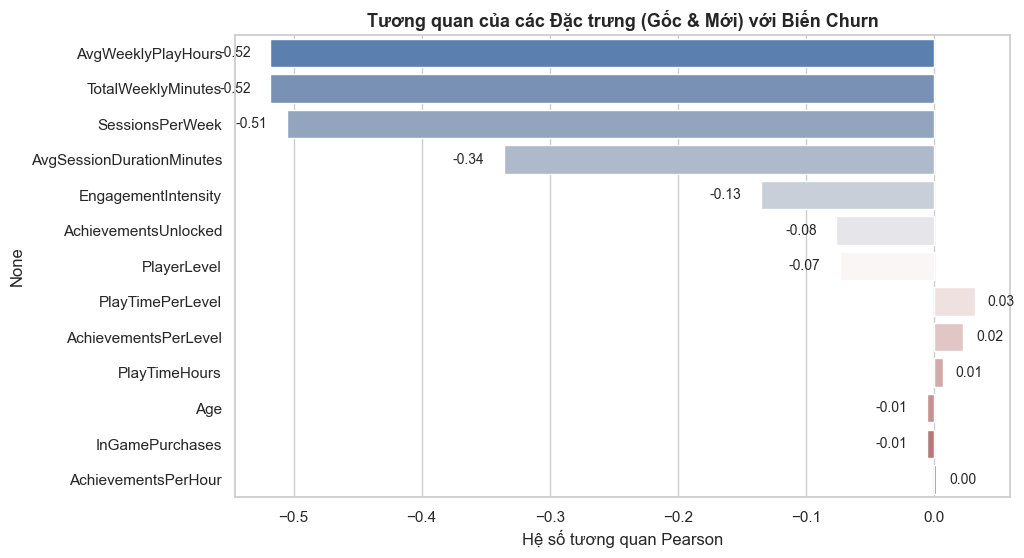

In [5]:
# 5. So sánh tương quan với Churn
num_features_all = df.select_dtypes(include=[np.number]).columns.drop(['PlayerID', 'IsChurn', 'EngagementCode'])
churn_corrs = df[num_features_all].apply(lambda col: col.corr(df['IsChurn'])).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_corrs.values, y=churn_corrs.index, palette='vlag')
plt.title('Tương quan của các Đặc trưng (Gốc & Mới) với Biến Churn', fontsize=13, fontweight='bold')
plt.xlabel('Hệ số tương quan Pearson')
for i, val in enumerate(churn_corrs.values):
    plt.text(val + (0.01 if val >= 0 else -0.04), i, f'{val:.2f}', va='center', fontsize=10)
plt.show()

---
## 5. Mã hóa Biến Phân loại (Categorical Encoding)
- **`GameDifficulty`:** Mã hóa có thứ tự (Ordinal Encoding): `{'Easy': 1, 'Medium': 2, 'Hard': 3}`.
- **`Gender`:** Nhị phân hóa (`Male`: 1, `Female`: 0).
- **`GameGenre` & `Location`:** One-Hot Encoding (`pd.get_dummies` với `drop_first=True` để loại bỏ đa cộng tuyến).

In [6]:
# 6. Thực hiện Encoding
df_encoded = df.copy()

# Ordinal Encoding
difficulty_map = {'Easy': 1, 'Medium': 2, 'Hard': 3}
df_encoded['GameDifficulty'] = df_encoded['GameDifficulty'].map(difficulty_map)

# Binary Encoding cho Gender
df_encoded['IsMale'] = (df_encoded['Gender'] == 'Male').astype(int)
df_encoded = df_encoded.drop(columns=['Gender'])

# One-Hot Encoding cho GameGenre và Location
df_encoded = pd.get_dummies(df_encoded, columns=['GameGenre', 'Location'], drop_first=True, dtype=int)

print(f"Kích thước sau khi mã hóa: {df_encoded.shape[1]} cột")
df_encoded.head()

Kích thước sau khi mã hóa: 26 cột


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,IsChurn,EngagementCode,TotalWeeklyMinutes,AvgWeeklyPlayHours,PlayTimePerLevel,AchievementsPerLevel,AchievementsPerHour,EngagementIntensity,IsMale,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,Location_Europe,Location_Other,Location_USA
0,9000,43,16.271,0,2,6,108,79,25,Medium,0,1,648,10.800,0.206,0.316,1.536,6.253,1,0,0,0,1,0,1,0
1,9001,29,5.526,0,2,5,144,11,10,Medium,0,1,720,12.000,0.502,0.909,1.810,22.066,0,0,0,0,1,0,0,1
2,9002,22,8.224,0,1,16,142,35,41,High,0,2,2272,37.867,0.235,1.171,4.986,15.395,0,0,0,1,0,0,0,1
3,9003,35,5.265,1,1,9,85,57,47,Medium,0,1,765,12.750,0.092,0.825,8.926,13.567,1,0,0,0,0,0,0,1
4,9004,33,15.532,0,2,2,131,95,37,Medium,0,1,262,4.367,0.163,0.389,2.382,7.924,1,0,0,0,0,1,0,0


---
## 6. Phân chia Train/Test & Chuẩn hóa Đặc trưng (Data Splitting & Scaling)
> **Nguyên tắc chống rò rỉ dữ liệu (Preventing Data Leakage):**
> Luôn phân chia tập **Train (80%)** và **Test (20%)** TRƯỚC khi fit `StandardScaler`. Scaler chỉ được fit trên tập Train và dùng để transform tập Test.

In [7]:
# 7. Tách Features (X) và Target (y)
DROP_COLS = ['PlayerID', 'EngagementLevel', 'EngagementCode', 'IsChurn']
feature_cols = [c for c in df_encoded.columns if c not in DROP_COLS]

X = df_encoded[feature_cols]
y = df_encoded['IsChurn']

print(f"Tổng số đặc trưng đầu vào cho mô hình: {len(feature_cols)}")
print("Danh sách đặc trưng:", feature_cols)

# Phân chia 80% Train, 20% Test (phân tầng theo biến mục tiêu stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"• Kích thước tập Train: {X_train.shape[0]:,} mẫu")
print(f"• Kích thước tập Test : {X_test.shape[0]:,} mẫu")

Tổng số đặc trưng đầu vào cho mô hình: 22
Danh sách đặc trưng: ['Age', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'TotalWeeklyMinutes', 'AvgWeeklyPlayHours', 'PlayTimePerLevel', 'AchievementsPerLevel', 'AchievementsPerHour', 'EngagementIntensity', 'IsMale', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'Location_Europe', 'Location_Other', 'Location_USA']
• Kích thước tập Train: 32,027 mẫu
• Kích thước tập Test : 8,007 mẫu


In [8]:
# 8. Chuẩn hóa đặc trưng bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("Đã fit và transform StandardScaler thành công!")
X_train_scaled.head()

Đã fit và transform StandardScaler thành công!


,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,TotalWeeklyMinutes,AvgWeeklyPlayHours,PlayTimePerLevel,AchievementsPerLevel,AchievementsPerHour,EngagementIntensity,IsMale,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,Location_Europe,Location_Other,Location_USA
11861,-1.588,-1.629,-0.502,-0.896,0.958,-0.154,-0.578,0.520,0.531,0.531,-0.362,-0.095,0.019,2.231,-1.224,-0.497,2.004,-0.502,-0.500,-0.651,3.020,-0.817
8411,1.396,-0.487,-0.502,-0.896,-0.777,0.621,-0.822,0.728,-0.351,-0.351,-0.180,0.016,-0.013,0.018,0.817,-0.497,2.004,-0.502,-0.500,-0.651,-0.331,1.223
7861,1.098,0.084,-0.502,-0.896,1.479,-0.970,-0.298,1.558,-0.064,-0.064,-0.195,-0.043,-0.013,-0.537,-1.224,-0.497,-0.499,1.993,-0.500,1.536,-0.331,-0.817
28680,1.694,0.696,1.991,-0.896,-0.603,-0.317,0.436,-0.656,-0.547,-0.547,-0.215,-0.308,-0.015,-0.481,0.817,-0.497,2.004,-0.502,-0.500,-0.651,-0.331,-0.817
26609,0.302,-0.699,-0.502,-0.896,-0.083,-1.358,0.331,-0.103,-0.835,-0.835,-0.303,-0.265,-0.013,-0.539,-1.224,2.012,-0.499,-0.502,-0.500,-0.651,-0.331,1.223


---
## 7. Lưu trữ Dữ liệu Đã Xử Lý & Preprocessor Artifacts
Xuất dữ liệu sạch ra thư mục `data/processed/` và lưu model scaler ra thư mục `models/` để phục vụ cho **Notebook 03 Modeling** và **API Deployment**.

In [9]:
# 9. Xuất dữ liệu đã xử lý ra data/processed/
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')

if not PROCESSED_DIR.exists():
    PROCESSED_DIR = Path('data/processed')
if not MODELS_DIR.exists():
    MODELS_DIR = Path('models')

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Ghép lại tập Train và Test đầy đủ kèm nhãn để lưu trữ
train_df = X_train_scaled.copy()
train_df['IsChurn'] = y_train

test_df = X_test_scaled.copy()
test_df['IsChurn'] = y_test

# Lưu files CSV
train_df.to_csv(PROCESSED_DIR / 'train_features.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_features.csv', index=False)

# Toàn bộ dữ liệu encoded (unscaled) kèm nhãn để phân tích hoặc cho mô hình cây (tree-based)
df_encoded.to_csv(PROCESSED_DIR / 'gaming_features_all.csv', index=False)

# Lưu scaler artifact và danh sách tên cột
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
joblib.dump(feature_cols, MODELS_DIR / 'feature_names.joblib')

print("🎉 ĐÃ HOÀN TẤT VÀ LƯU DỮ LIỆU THÀNH CÔNG:")
print(f"1. {PROCESSED_DIR / 'train_features.csv'} ({train_df.shape[0]:,} dòng, {train_df.shape[1]} cột)")
print(f"2. {PROCESSED_DIR / 'test_features.csv'} ({test_df.shape[0]:,} dòng, {test_df.shape[1]} cột)")
print(f"3. {PROCESSED_DIR / 'gaming_features_all.csv'} ({df_encoded.shape[0]:,} dòng, {df_encoded.shape[1]} cột)")
print(f"4. {MODELS_DIR / 'scaler.joblib'}")
print(f"5. {MODELS_DIR / 'feature_names.joblib'}")

🎉 ĐÃ HOÀN TẤT VÀ LƯU DỮ LIỆU THÀNH CÔNG:
1. ..\data\processed\train_features.csv (32,027 dòng, 23 cột)
2. ..\data\processed\test_features.csv (8,007 dòng, 23 cột)
3. ..\data\processed\gaming_features_all.csv (40,034 dòng, 26 cột)
4. ..\models\scaler.joblib
5. ..\models\feature_names.joblib


---
## 8. Kết Luận & Chuẩn Bị Cho Notebook 03 (Modeling)

### 📌 Thành quả đạt được:
1. **Tính toán chính xác các đặc trưng hành vi:** `PlayTimePerLevel` và `AchievementsPerLevel` được tính trực tiếp trên `PlayerLevel` (với điều kiện loại trừ Level 0), không làm suy giảm giá trị thực tế của chỉ số ở các level cao.
2. **Chuẩn bị 20 đặc trưng số hóa hoàn chỉnh** sau khi mã hóa Ordinal & One-Hot Encoding.
3. **Tách tập Train (32,027 mẫu) và Test (8,007 mẫu)** theo tỷ lệ 80/20 có phân tầng nhãn `IsChurn`.
4. **Chuẩn hóa dữ liệu** và lưu trữ file artifacts sẵn sàng trong `data/processed/` và `models/`.

👉 **Bước tiếp theo:** Chuyển sang **[03_Modeling.ipynb](03_Modeling.ipynb)** để huấn luyện các mô hình Baseline (Logistic Regression, Random Forest, XGBoost), tối ưu siêu tham số và phân tích SHAP Explainability!